## SHAP

# Tree ensemble example (XGBoost/LightGBM/CatBoost/scikit-learn/pyspark models)

In [2]:
!pip install -q shap xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00


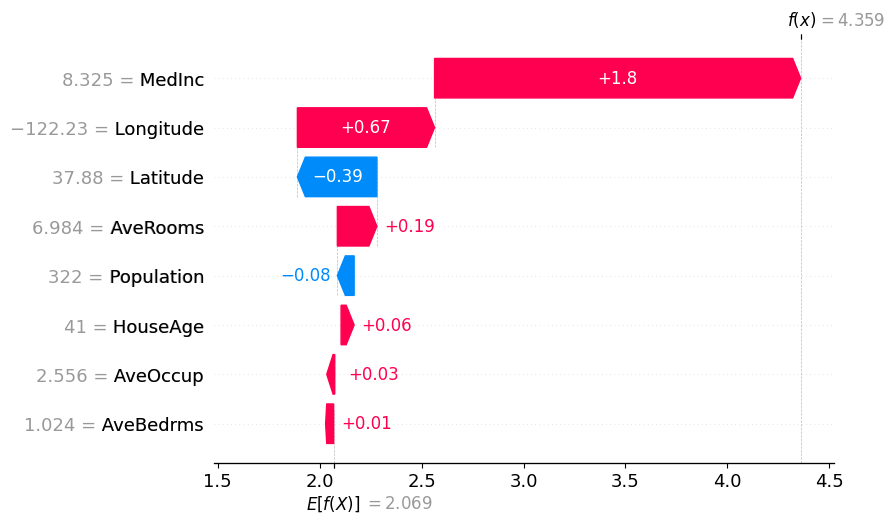

In [3]:
import xgboost
import shap

# train an XGBoost model
X, y = shap.datasets.california()
model = xgboost.XGBRegressor().fit(X, y)

# explain the model's predictions using SHAP
# (same syntax works for LightGBM, CatBoost, scikit-learn, transformers, Spark, etc.)
explainer = shap.Explainer(model)
shap_values = explainer(X)

# visualize the first prediction's explanation
shap.plots.waterfall(shap_values[0])

The general-purpose shap.Explainer interface dynamically inspects the supplied model architecture and input data, automatically defaulting to the optimized TreeSHAP algorithm when applied to tree-based ensembles such as XGBoost.

The above explanation shows features each contributing to push the model output from the base value (the average model output over the training dataset we passed) to the model output. Features pushing the prediction higher are shown in red, those pushing the prediction lower are in blue. Another way to visualize the same explanation is to use a force plot (these are introduced in our Nature BME paper)

In [4]:
# visualize the first prediction's explanation with a force plot
shap.initjs()
shap.plots.force(shap_values[0])

If we take many force plot explanations such as the one shown above, rotate them 90 degrees, and then stack them horizontally, we can see explanations for an entire dataset (in the notebook this plot is interactive):



In [5]:
# visualize all the training set predictions
shap.initjs()
shap.plots.force(shap_values[:500])

To understand how a single feature effects the output of the model we can plot the SHAP value of that feature vs. the value of the feature for all the examples in a dataset. Since SHAP values represent a feature's responsibility for a change in the model output, the plot below represents the change in predicted house price as the latitude changes. Vertical dispersion at a single value of latitude represents interaction effects with other features. To help reveal these interactions we can color by another feature. If we pass the whole explanation tensor to the color argument the scatter plot will pick the best feature to color by. In this case it picks longitude.

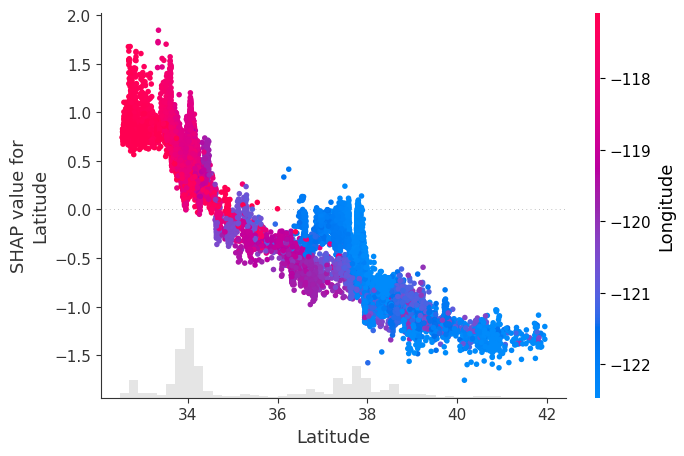

In [6]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.initjs()
shap.plots.scatter(shap_values[:, "Latitude"], color=shap_values)

To get an overview of which features are most important for a model we can plot the SHAP values of every feature for every sample. The plot below sorts features by the sum of SHAP value magnitudes over all samples, and uses SHAP values to show the distribution of the impacts each feature has on the model output. The color represents the feature value (red high, blue low). This reveals for example that higher median incomes increases the predicted home price.

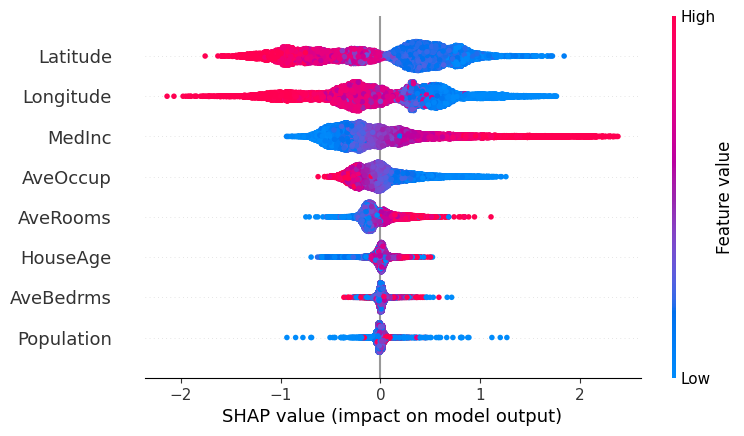

In [7]:
# summarize the effects of all the features
shap.plots.beeswarm(shap_values)

We can also just take the mean absolute value of the SHAP values for each feature to get a standard bar plot (produces stacked bars for multi-class outputs):

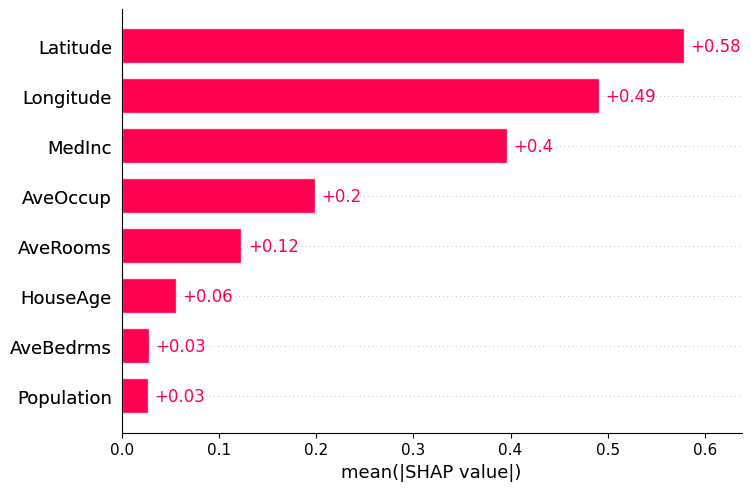

In [8]:
shap.plots.bar(shap_values)

# Model agnostic example with KernelExplainer (explains any function)



Kernel SHAP uses a specially-weighted local linear regression to estimate SHAP values for any model. Below is a simple example for explaining a multi-class SVM on the classic iris dataset.

In [9]:
import sklearn
import shap
from sklearn.model_selection import train_test_split

# print the JS visualization code to the notebook
shap.initjs()

# train a SVM classifier
X_train,X_test,Y_train,Y_test = train_test_split(*shap.datasets.iris(), test_size=0.2, random_state=0)
svm = sklearn.svm.SVC(kernel='rbf', probability=True)
svm.fit(X_train, Y_train)

# use Kernel SHAP to explain test set predictions
explainer = shap.KernelExplainer(svm.predict_proba, X_train, link="logit")
shap_values = explainer.shap_values(X_test, nsamples=100)

# plot the SHAP values for the Setosa output of the first instance
shap.force_plot(explainer.expected_value[0], shap_values[0, :, 0], X_test.iloc[0], link="logit")

  0%|          | 0/30 [00:00<?, ?it/s]

The above explanation shows four features each contributing to push the model output from the base value (the average model output over the training dataset we passed) towards zero. If there were any features pushing the class label higher they would be shown in red.

If we take many explanations such as the one shown above, rotate them 90 degrees, and then stack them horizontally, we can see explanations for an entire dataset. This is exactly what we do below for all the examples in the iris test set:

In [10]:
# plot the SHAP values for the Setosa output of all instances
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[:, :, 0], X_test, link="logit")

# SHAP Interaction Values


SHAP interaction values are a generalization of SHAP values to higher order interactions. Fast exact computation of pairwise interactions are implemented for tree models with shap.TreeExplainer(model).shap_interaction_values(X). This returns a matrix for every prediction, where the main effects are on the diagonal and the interaction effects are off-diagonal. These values often reveal interesting hidden relationships, such as how the increased risk of death peaks for men at age 60 (see the NHANES notebook for details):
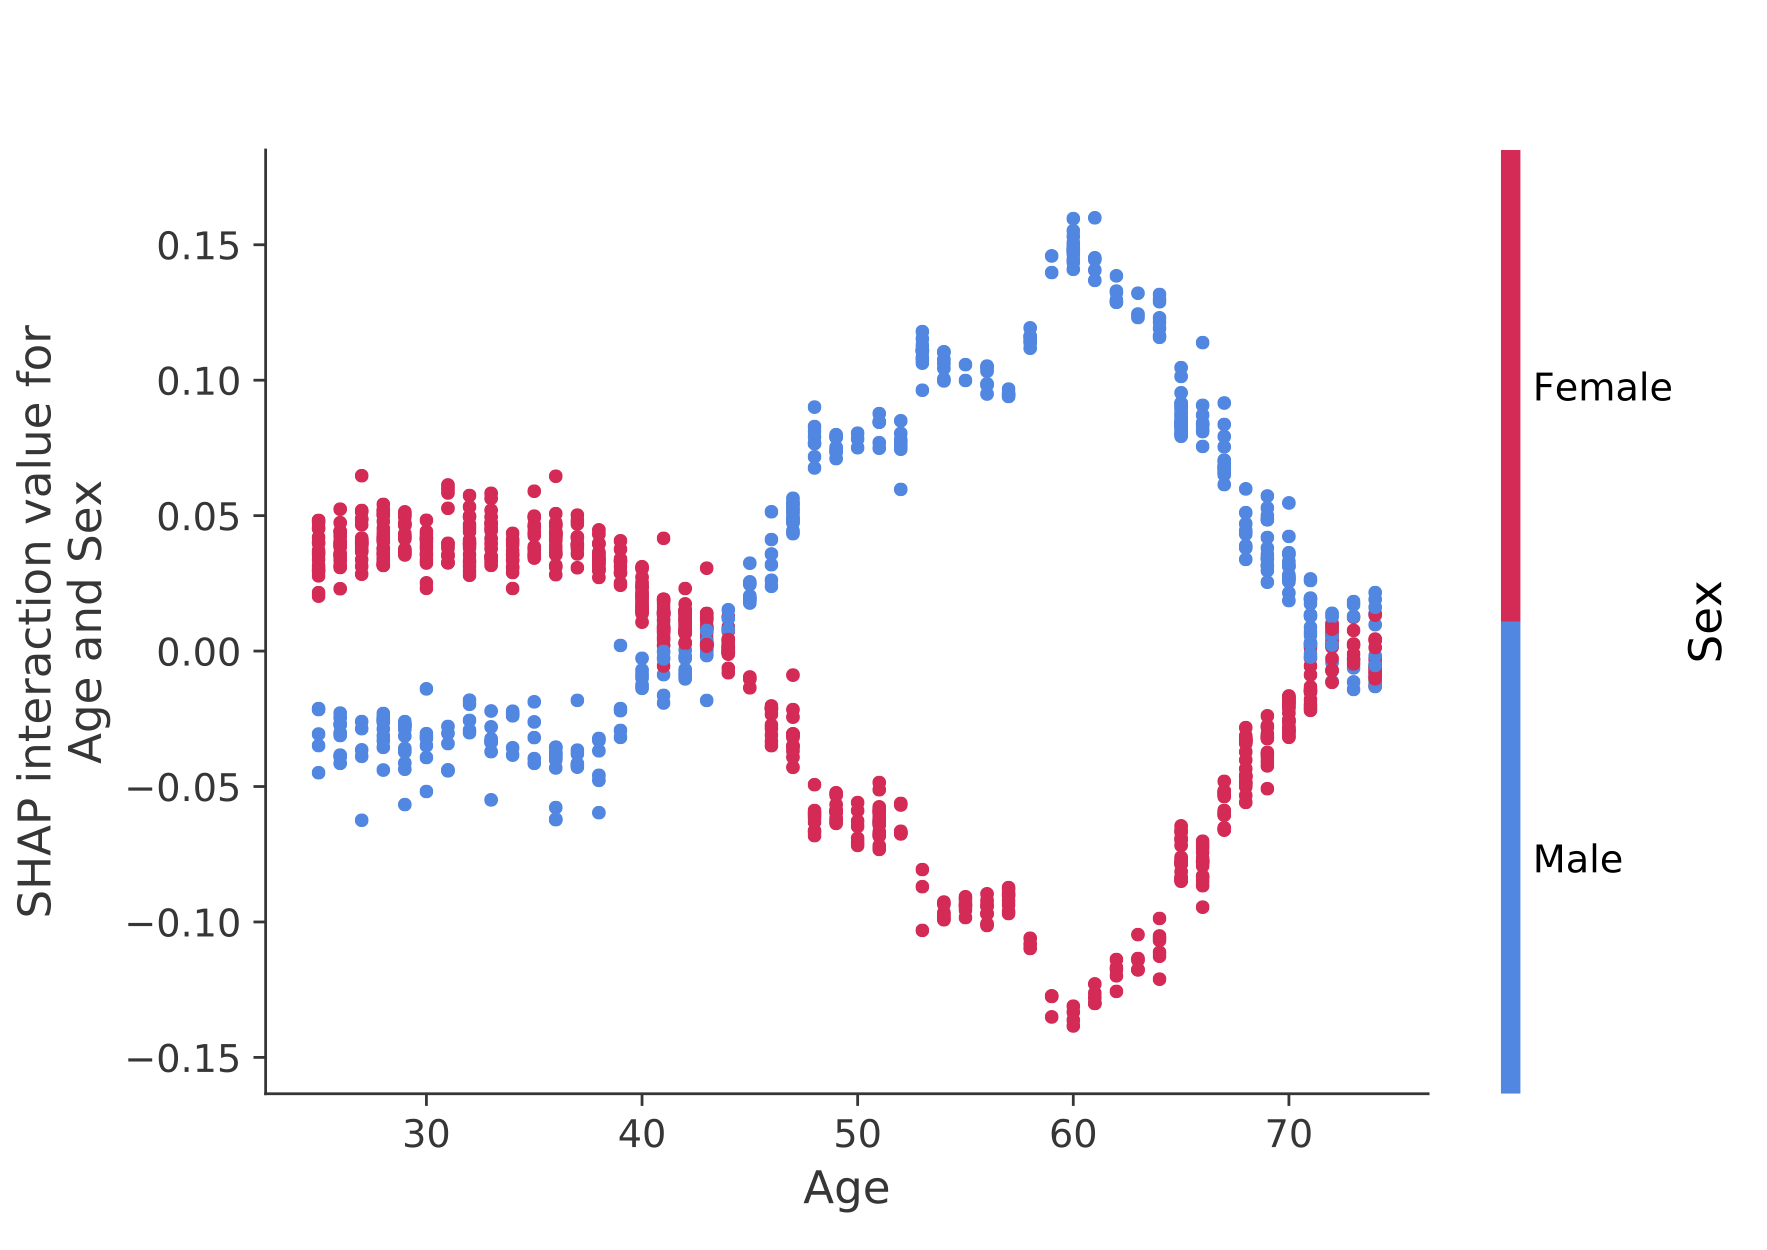

# Deep learning example with GradientExplainer (TensorFlow/Keras/PyTorch models)


Deep SHAP is a high-speed approximation algorithm for SHAP values in deep learning models that builds on a connection with DeepLIFT described in the SHAP NIPS paper. The implementation here differs from the original DeepLIFT by using a distribution of background samples instead of a single reference value, and using Shapley equations to linearize components such as max, softmax, products, divisions, etc. Note that some of these enhancements have also been since integrated into DeepLIFT. TensorFlow models and Keras models using the TensorFlow backend are supported (there is also preliminary support for PyTorch):

In [1]:
import os
# 1. Αναγκάζει το περιβάλλον να χρησιμοποιήσει το legacy tf-keras (Keras 2)
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
# 2. Απενεργοποίηση eager execution στην αρχή, πριν χτιστεί το μοντέλο
tf.compat.v1.disable_eager_execution()

import numpy as np
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Convert class vectors to binary class matrices
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

batch_size = 128
epochs = 3

model = Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.compile(
    loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
)

model.fit(
    x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1
)

score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Train on 54000 samples, validate on 6000 samples
Epoch 1/3
54000/54000 [==============================] - ETA: 0s - loss: 0.3630 - accuracy: 0.8900

/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training_v1.py:2330: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


54000/54000 [==============================] - 24s 438us/sample - loss: 0.3630 - accuracy: 0.8900 - val_loss: 0.0801 - val_accuracy: 0.9768
Epoch 2/3
54000/54000 [==============================] - 24s 453us/sample - loss: 0.1114 - accuracy: 0.9662 - val_loss: 0.0562 - val_accuracy: 0.9850
Epoch 3/3
54000/54000 [==============================] - 24s 441us/sample - loss: 0.0841 - accuracy: 0.9742 - val_loss: 0.0468 - val_accuracy: 0.9880
Test loss: 0.047101893
Test accuracy: 0.9852


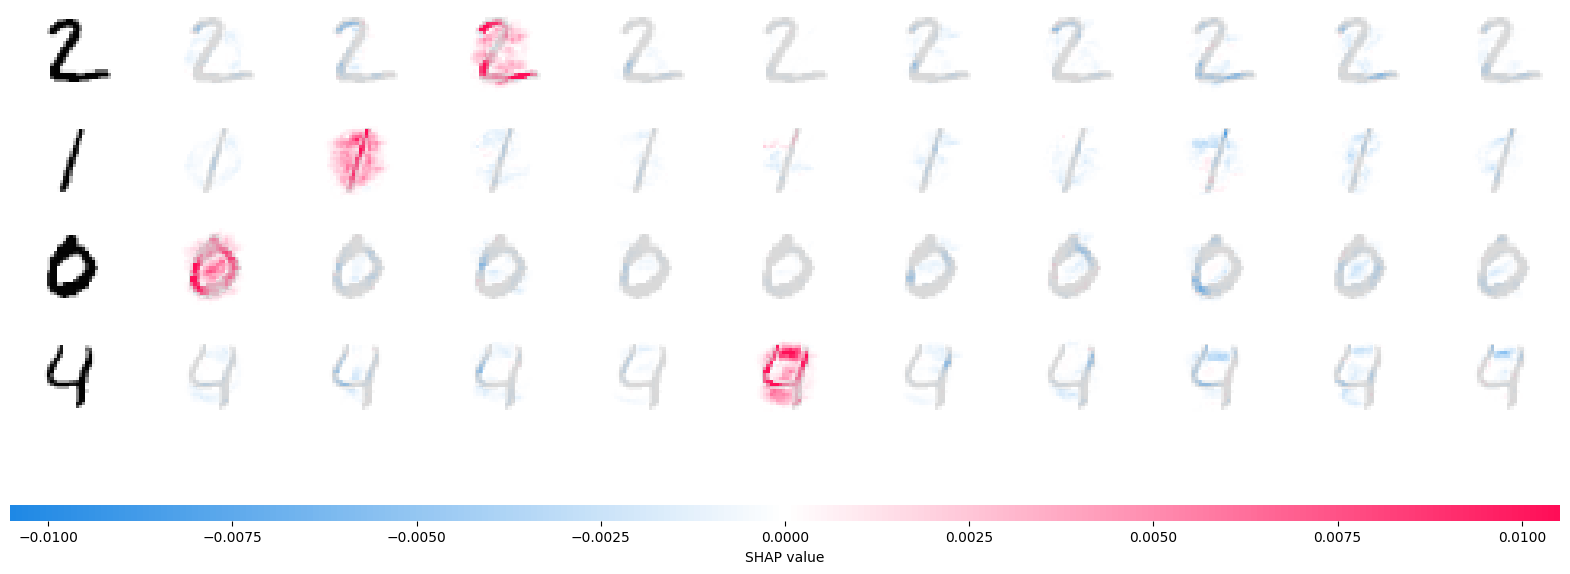

In [6]:
# ...include code from https://github.com/keras-team/keras/blob/master/examples/demo_mnist_convnet.py

import shap
import numpy as np

# select a set of background examples to take an expectation over
background = x_train[np.random.choice(x_train.shape[0], 100, replace=False)]

# explain predictions of the model on four images
e = shap.DeepExplainer(model, background)
# ...or pass tensors directly
# e = shap.DeepExplainer((model.layers[0].input, model.layers[-1].output), background)
shap_values = e.shap_values(x_test[1:5])

# plot the feature attributions

# shap.image_plot(shap_values, -x_test[1:5]) -> Correction:

shap_list = [shap_values[:, :, :, :, i] for i in range(10)]
shap.image_plot(shap_list, -x_test[1:5])

The correction was necessary because evaluating multiclass predictions with modern SHAP versions returns a 5D array of shape (samples, height, width, channels, classes), which shap.image_plot misinterprets as multiple channels for a single class unless explicitly partitioned into a list of 4D arrays for each target class.

The plot above explains ten outputs (digits 0-9) for four different images. Red pixels increase the model's output while blue pixels decrease the output. The input images are shown on the left, and as nearly transparent grayscale backings behind each of the explanations. The sum of the SHAP values equals the difference between the expected model output (averaged over the background dataset) and the current model output. Note that for the 'zero' image the blank middle is important, while for the 'four' image the lack of a connection on top makes it a four instead of a nine.



# Natural language example (transformers)


SHAP has specific support for natural language models like those in the Hugging Face transformers library. By adding coalitional rules to traditional Shapley values we can form games that explain large modern NLP model using very few function evaluations. Using this functionality is as simple as passing a supported transformers pipeline to SHAP:



In [7]:
import transformers
import shap

# load a transformers pipeline model
model = transformers.pipeline('sentiment-analysis', top_k=None)

# explain the model on two sample inputs
explainer = shap.Explainer(model)
shap_values = explainer(["What a great movie! ...if you have no taste."])

# visualize the first prediction's explanation for the POSITIVE output class
shap.plots.text(shap_values[0, :, "POSITIVE"])

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:23, 23.29s/it]               


The experimental demonstration scenarios were selected to validate the framework across supported learning tasks (Regression and Classification) and input data structures (Tabular, Vision, and Text). Structured tabular data represents the operational core of the targeted decision support systems; therefore, both continuous output prediction via tree-based Shapley value computation and discrete classification via model-agnostic kernel estimation are implemented on tabular inputs. The image and text modalities serve as complementary benchmarks, demonstrating the broader generalizability of the explainability framework across high-dimensional and unstructured data formats.